Cell 1 — Load the full dataset

In [11]:
# ============================================================
# GLOBAL LSTM — LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


model_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stock_macro_monthly_target.parquet"

df = pd.read_parquet(model_path)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["isin", "date"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Stocks:", df["isin"].nunique())
print("Date range:", df["date"].min(), "→", df["date"].max())

Shape: (60846, 23)
Stocks: 437
Date range: 2010-01-01 00:00:00 → 2026-09-01 00:00:00


Cell 2 — Create global features

In [12]:
# ============================================================
# GLOBAL FEATURE ENGINEERING
# ============================================================

global_data = df[
    [
        "isin",
        "symbol",
        "date",
        "monthly_adj_close",
        "monthly_volume",
        "stock_return_1m",
        "oil_return_1m_pct",
        "gold_return_1m_pct",
        "target_return_1m"
    ]
].copy()


# ------------------------------------------------------------
# Stock momentum
# ------------------------------------------------------------

global_data["stock_return_3m"] = (
    global_data
    .groupby("isin")["monthly_adj_close"]
    .pct_change(3) * 100
)

global_data["stock_return_6m"] = (
    global_data
    .groupby("isin")["monthly_adj_close"]
    .pct_change(6) * 100
)


# ------------------------------------------------------------
# Stock volatility
# ------------------------------------------------------------

global_data["stock_volatility_3m"] = (
    global_data
    .groupby("isin")["stock_return_1m"]
    .rolling(3)
    .std()
    .reset_index(level=0, drop=True)
)


# ------------------------------------------------------------
# Volume change
# ------------------------------------------------------------

global_data["volume_change_1m"] = (
    global_data
    .groupby("isin")["monthly_volume"]
    .pct_change() * 100
)


features = [
    "stock_return_1m",
    "stock_return_3m",
    "stock_return_6m",
    "stock_volatility_3m",
    "volume_change_1m",
    "oil_return_1m_pct",
    "gold_return_1m_pct"
]

target = "target_return_1m"


print("Features:")
for f in features:
    print(" -", f)

Features:
 - stock_return_1m
 - stock_return_3m
 - stock_return_6m
 - stock_volatility_3m
 - volume_change_1m
 - oil_return_1m_pct
 - gold_return_1m_pct


In [13]:
# ============================================================
# FINAL GLOBAL LSTM CLEANUP
# ============================================================

# Replace infinity with NaN
global_data[features] = global_data[features].replace(
    [np.inf, -np.inf],
    np.nan
)

# Check how many rows are affected
print("Rows before removing invalid values:", len(global_data))

invalid_rows = global_data[
    global_data[features].isna().any(axis=1)
]

print("Invalid rows:", len(invalid_rows))

if len(invalid_rows) > 0:
    print("\nAffected rows:")
    display(
        invalid_rows[
            ["isin", "symbol", "date"] + features
        ]
    )

# Remove them
global_data = global_data.dropna(
    subset=features + [target]
).copy()

global_data = (
    global_data
    .sort_values(["isin", "date"])
    .reset_index(drop=True)
)

print("\nRows after cleanup:", len(global_data))

print("\nRemaining NaN:")
print(global_data[features].isna().sum())

print("\nRemaining infinity:")
print(np.isinf(global_data[features]).sum())

Rows before removing invalid values: 60846
Invalid rows: 2608

Affected rows:


,isin,symbol,date,stock_return_1m,stock_return_3m,stock_return_6m,stock_volatility_3m,volume_change_1m,oil_return_1m_pct,gold_return_1m_pct
0,INE002A01018,RELIANCE,2010-01-01,-4.066738,NaN,NaN,NaN,NaN,NaN,NaN
1,INE002A01018,RELIANCE,2010-02-01,-6.428039,NaN,NaN,NaN,-49.507187,8.578222,3.192272
2,INE002A01018,RELIANCE,2010-03-01,9.734929,NaN,NaN,8.730247,29.249698,6.585901,-3.187257
3,INE002A01018,RELIANCE,2010-04-01,-3.784027,-1.204357,NaN,8.669818,-10.160069,5.731567,4.698833
4,INE002A01018,RELIANCE,2010-05-01,1.909299,7.598416,NaN,6.787447,26.170265,-15.347673,7.613534
...,...,...,...,...,...,...,...,...,...,...
60807,INF179KC1965,HDFCNIFTY,2023-07-01,2.795628,NaN,NaN,NaN,-23.162391,14.232304,2.793144
60808,INF179KC1965,HDFCNIFTY,2023-08-01,-1.586040,NaN,NaN,NaN,91.986217,1.519405,-1.103923
60809,INF179KC1965,HDFCNIFTY,2023-09-01,2.057163,3.246382,NaN,2.345821,23.722322,9.728295,-4.080688
60810,INF179KC1965,HDFCNIFTY,2023-10-01,-2.902791,-2.477025,NaN,2.569303,61.103025,-6.547055,5.231416



Rows after cleanup: 57815

Remaining NaN:
stock_return_1m        0
stock_return_3m        0
stock_return_6m        0
stock_volatility_3m    0
volume_change_1m       0
oil_return_1m_pct      0
gold_return_1m_pct     0
dtype: int64

Remaining infinity:
stock_return_1m        0
stock_return_3m        0
stock_return_6m        0
stock_volatility_3m    0
volume_change_1m       0
oil_return_1m_pct      0
gold_return_1m_pct     0
dtype: int64


Cell 3 — Remove unusable rows

In [14]:
# ============================================================
# REMOVE MISSING FEATURE/TARGET ROWS
# ============================================================

global_data = global_data.dropna(
    subset=features + [target]
).copy()

global_data = (
    global_data
    .sort_values(["isin", "date"])
    .reset_index(drop=True)
)

print("After cleaning:")
print("Rows:", len(global_data))
print("Stocks:", global_data["isin"].nunique())
print(
    "Date range:",
    global_data["date"].min(),
    "→",
    global_data["date"].max()
)

print("\nMissing values:")
print(global_data[features + [target]].isna().sum())

After cleaning:
Rows: 57815
Stocks: 421
Date range: 2010-07-01 00:00:00 → 2026-08-01 00:00:00

Missing values:
stock_return_1m        0
stock_return_3m        0
stock_return_6m        0
stock_volatility_3m    0
volume_change_1m       0
oil_return_1m_pct      0
gold_return_1m_pct     0
target_return_1m       0
dtype: int64


Cell 4 — Define the date-based splits

In [15]:
# ============================================================
# GLOBAL DATE SPLITS
# ============================================================

TRAIN_END = pd.Timestamp("2021-09-01")
VAL_END = pd.Timestamp("2024-08-01")
TEST_END = pd.Timestamp("2026-08-01")

train_data = global_data[
    global_data["date"] <= TRAIN_END
].copy()

val_data = global_data[
    (global_data["date"] > TRAIN_END) &
    (global_data["date"] <= VAL_END)
].copy()

test_data = global_data[
    (global_data["date"] > VAL_END) &
    (global_data["date"] <= TEST_END)
].copy()


print("=" * 70)
print("GLOBAL LSTM DATE SPLIT")
print("=" * 70)

print("\nTrain:")
print(len(train_data))
print(train_data["date"].min(), "→", train_data["date"].max())

print("\nValidation:")
print(len(val_data))
print(val_data["date"].min(), "→", val_data["date"].max())

print("\nTest:")
print(len(test_data))
print(test_data["date"].min(), "→", test_data["date"].max())

GLOBAL LSTM DATE SPLIT

Train:
36089
2010-07-01 00:00:00 → 2021-09-01 00:00:00

Validation:
12289
2021-10-01 00:00:00 → 2024-08-01 00:00:00

Test:
9437
2024-09-01 00:00:00 → 2026-08-01 00:00:00


Cell 5 — Fit the scaler correctly

In [16]:
# ============================================================
# CELL 7 — SCALE FEATURES
# ============================================================

scaler = StandardScaler()

scaler.fit(train_data[features])

global_data_scaled = global_data.copy()

global_data_scaled[features] = scaler.transform(
    global_data[features]
)

print("Scaler fitted successfully.")

print("\nTraining means:")
print(
    global_data_scaled.loc[
        global_data_scaled["date"] <= TRAIN_END,
        features
    ].mean().round(6)
)

print("\nTraining standard deviations:")
print(
    global_data_scaled.loc[
        global_data_scaled["date"] <= TRAIN_END,
        features
    ].std().round(6)
)

Scaler fitted successfully.

Training means:
stock_return_1m       -0.0
stock_return_3m        0.0
stock_return_6m       -0.0
stock_volatility_3m    0.0
volume_change_1m      -0.0
oil_return_1m_pct      0.0
gold_return_1m_pct     0.0
dtype: float64

Training standard deviations:
stock_return_1m        1.000014
stock_return_3m        1.000014
stock_return_6m        1.000014
stock_volatility_3m    1.000014
volume_change_1m       1.000014
oil_return_1m_pct      1.000014
gold_return_1m_pct     1.000014
dtype: float64


In [17]:
print("NaN:")
print(global_data[features].isna().sum())

print("\nInfinity:")
print(np.isinf(global_data[features]).sum())

NaN:
stock_return_1m        0
stock_return_3m        0
stock_return_6m        0
stock_volatility_3m    0
volume_change_1m       0
oil_return_1m_pct      0
gold_return_1m_pct     0
dtype: int64

Infinity:
stock_return_1m        0
stock_return_3m        0
stock_return_6m        0
stock_volatility_3m    0
volume_change_1m       0
oil_return_1m_pct      0
gold_return_1m_pct     0
dtype: int64


Cell 8 — Define sequence creation function

In [19]:
# ============================================================
# CELL 8 — GLOBAL LSTM SEQUENCE FUNCTION
# ============================================================

LOOKBACK = 12


def create_global_sequences(
    data,
    features,
    target,
    lookback,
    train_end,
    val_end,
    test_end
):

    X_train = []
    y_train = []

    X_val = []
    y_val = []

    X_test = []
    y_test = []

    meta_train = []
    meta_val = []
    meta_test = []

    # Process each stock independently
    for isin, stock in data.groupby("isin", sort=False):

        stock = (
            stock
            .sort_values("date")
            .reset_index(drop=True)
        )

        X = stock[features].values
        y = stock[target].values
        dates = stock["date"].values

        for i in range(lookback, len(stock)):

            target_date = pd.Timestamp(dates[i])

            # ------------------------------------------------
            # Check that previous 12 observations are actually
            # 12 consecutive months
            # ------------------------------------------------

            sequence_dates = pd.to_datetime(
                dates[i-lookback:i]
            )

            expected_dates = pd.date_range(
                start=sequence_dates[0],
                periods=lookback,
                freq="MS"
            )

            if not np.array_equal(
                sequence_dates.values,
                expected_dates.values
            ):
                continue

            sequence = X[i-lookback:i]
            target_value = y[i]

            # ------------------------------------------------
            # TRAIN
            # ------------------------------------------------

            if target_date <= train_end:

                X_train.append(sequence)
                y_train.append(target_value)

                meta_train.append(
                    (isin, target_date)
                )

            # ------------------------------------------------
            # VALIDATION
            # ------------------------------------------------

            elif target_date <= val_end:

                X_val.append(sequence)
                y_val.append(target_value)

                meta_val.append(
                    (isin, target_date)
                )

            # ------------------------------------------------
            # TEST
            # ------------------------------------------------

            elif target_date <= test_end:

                X_test.append(sequence)
                y_test.append(target_value)

                meta_test.append(
                    (isin, target_date)
                )

    return (
        np.array(X_train, dtype=np.float32),
        np.array(y_train, dtype=np.float32),

        np.array(X_val, dtype=np.float32),
        np.array(y_val, dtype=np.float32),

        np.array(X_test, dtype=np.float32),
        np.array(y_test, dtype=np.float32),

        meta_train,
        meta_val,
        meta_test
    )

In [20]:
# ============================================================
# CELL 8 — GLOBAL LSTM SEQUENCE FUNCTION
# ============================================================

LOOKBACK = 12


def create_global_sequences(
    data,
    features,
    target,
    lookback,
    train_end,
    val_end,
    test_end
):

    X_train = []
    y_train = []

    X_val = []
    y_val = []

    X_test = []
    y_test = []

    meta_train = []
    meta_val = []
    meta_test = []

    # Process each stock independently
    for isin, stock in data.groupby("isin", sort=False):

        stock = (
            stock
            .sort_values("date")
            .reset_index(drop=True)
        )

        X = stock[features].values
        y = stock[target].values
        dates = stock["date"].values

        for i in range(lookback, len(stock)):

            target_date = pd.Timestamp(dates[i])

            # ------------------------------------------------
            # Check that previous 12 observations are actually
            # 12 consecutive months
            # ------------------------------------------------

            sequence_dates = pd.to_datetime(
                dates[i-lookback:i]
            )

            expected_dates = pd.date_range(
                start=sequence_dates[0],
                periods=lookback,
                freq="MS"
            )

            if not np.array_equal(
                sequence_dates.values,
                expected_dates.values
            ):
                continue

            sequence = X[i-lookback:i]
            target_value = y[i]

            # ------------------------------------------------
            # TRAIN
            # ------------------------------------------------

            if target_date <= train_end:

                X_train.append(sequence)
                y_train.append(target_value)

                meta_train.append(
                    (isin, target_date)
                )

            # ------------------------------------------------
            # VALIDATION
            # ------------------------------------------------

            elif target_date <= val_end:

                X_val.append(sequence)
                y_val.append(target_value)

                meta_val.append(
                    (isin, target_date)
                )

            # ------------------------------------------------
            # TEST
            # ------------------------------------------------

            elif target_date <= test_end:

                X_test.append(sequence)
                y_test.append(target_value)

                meta_test.append(
                    (isin, target_date)
                )

    return (
        np.array(X_train, dtype=np.float32),
        np.array(y_train, dtype=np.float32),

        np.array(X_val, dtype=np.float32),
        np.array(y_val, dtype=np.float32),

        np.array(X_test, dtype=np.float32),
        np.array(y_test, dtype=np.float32),

        meta_train,
        meta_val,
        meta_test
    )

Cell 9 — Create all-stock sequences

In [21]:
# ============================================================
# CELL 9 — CREATE GLOBAL SEQUENCES
# ============================================================

(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    meta_train,
    meta_val,
    meta_test
) = create_global_sequences(
    global_data_scaled,
    features,
    target,
    LOOKBACK,
    TRAIN_END,
    VAL_END,
    TEST_END
)

print("=" * 70)
print("GLOBAL LSTM SEQUENCE SHAPES")
print("=" * 70)

print("\nTraining:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTesting:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

GLOBAL LSTM SEQUENCE SHAPES

Training:
X_train: (32273, 12, 7)
y_train: (32273,)

Validation:
X_val: (11653, 12, 7)
y_val: (11653,)

Testing:
X_test: (8984, 12, 7)
y_test: (8984,)


Cell 10 — Check stock coverage

In [22]:
# ============================================================
# CELL 10 — STOCK COVERAGE
# ============================================================

train_stocks = set(
    isin for isin, date in meta_train
)

val_stocks = set(
    isin for isin, date in meta_val
)

test_stocks = set(
    isin for isin, date in meta_test
)

print("Stocks in training:", len(train_stocks))
print("Stocks in validation:", len(val_stocks))
print("Stocks in testing:", len(test_stocks))

print("\nTraining sequences:", len(X_train))
print("Validation sequences:", len(X_val))
print("Test sequences:", len(X_test))

Stocks in training: 313
Stocks in validation: 360
Stocks in testing: 393

Training sequences: 32273
Validation sequences: 11653
Test sequences: 8984


Cell 11 — Build the global LSTM

In [ ]:
# ============================================================
# CELL 11 — GLOBAL LSTM MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    
    LSTM(
        64,
        input_shape=(LOOKBACK, len(features))
    ),

    Dropout(0.2),

    Dense(
        32,
        activation="relu"
    ),

    Dense(1)
])

model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

model.summary()

c:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\backend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

Cell 12 — Train

In [25]:
# ============================================================
# CELL 12 — TRAIN GLOBAL LSTM
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=100,
    batch_size=128,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

print("\nTraining completed.")
print(
    "Epochs trained:",
    len(history.history["loss"])
)

Epoch 1/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 135.1281 - mae: 8.2542 - val_loss: 104.5078 - val_mae: 7.6144
Epoch 2/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 128.7409 - mae: 8.0910 - val_loss: 110.6446 - val_mae: 7.8646
Epoch 3/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 121.0663 - mae: 7.8802 - val_loss: 109.8524 - val_mae: 7.8435
Epoch 4/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 111.3366 - mae: 7.5944 - val_loss: 106.2604 - val_mae: 7.6917
Epoch 5/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 107.9825 - mae: 7.4685 - val_loss: 110.9206 - val_mae: 7.8923
Epoch 6/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 105.4133 - mae: 7.3790 - val_loss: 106.0956 - val_mae: 7.6804
Epoch 7/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 103.7861 - mae: 7.3277 - val_loss: 110.5742 - val_mae: 7.8617
Epoch 8/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 102.4722 - mae: 7.2724 - val_loss: 109.4583 - val_mae: 7.8607
Epoch 9/10

Cell 13 — Plot training history

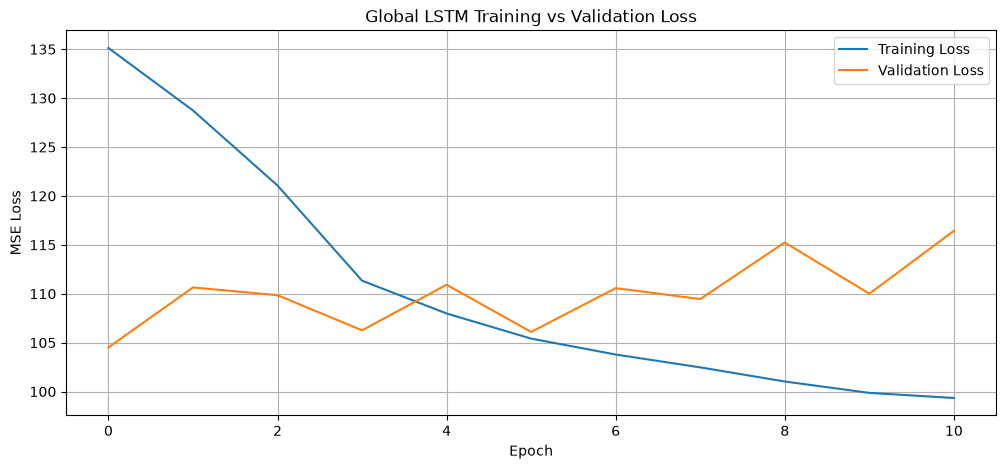

In [26]:
# ============================================================
# CELL 13 — TRAINING HISTORY
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Global LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

Cell 14 — Test predictions

In [27]:
# ============================================================
# CELL 14 — GLOBAL LSTM TEST PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test,
    batch_size=128,
    verbose=1
).flatten()

print("Predictions:", len(y_pred))
print("Actual:", len(y_test))

print("\nPrediction statistics:")
print(f"Min:  {y_pred.min():.4f}%")
print(f"Max:  {y_pred.max():.4f}%")
print(f"Mean: {y_pred.mean():.4f}%")

print("\nActual statistics:")
print(f"Min:  {y_test.min():.4f}%")
print(f"Max:  {y_test.max():.4f}%")
print(f"Mean: {y_test.mean():.4f}%")

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predictions: 8984
Actual: 8984

Prediction statistics:
Min:  -1.5565%
Max:  8.3707%
Mean: 0.1011%

Actual statistics:
Min:  -58.7573%
Max:  86.2070%
Mean: 0.1976%


Cell 15 — Evaluate Global LSTM

In [28]:
# ============================================================
# CELL 15 — GLOBAL LSTM EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

directional_accuracy = np.mean(
    np.sign(y_test) == np.sign(y_pred)
)

print("=" * 70)
print("GLOBAL LSTM TEST RESULTS")
print("=" * 70)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(
    f"Directional Accuracy: "
    f"{directional_accuracy * 100:.2f}%"
)

GLOBAL LSTM TEST RESULTS
MAE:  7.7560
RMSE: 10.5678
Directional Accuracy: 49.54%


In [29]:
# ============================================
# GLOBAL BASELINES
# ============================================

# Zero-return baseline
zero_pred = np.zeros_like(y_test)

zero_mae = mean_absolute_error(y_test, zero_pred)
zero_rmse = np.sqrt(mean_squared_error(y_test, zero_pred))
zero_direction = np.mean(np.sign(y_test) == np.sign(zero_pred))

# Mean-return baseline
mean_value = y_train.mean()
mean_pred = np.full_like(y_test, mean_value)

mean_mae = mean_absolute_error(y_test, mean_pred)
mean_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))
mean_direction = np.mean(np.sign(y_test) == np.sign(mean_pred))

print("=" * 70)
print("GLOBAL BASELINE COMPARISON")
print("=" * 70)

print("\nZero-return baseline:")
print(f"MAE: {zero_mae:.4f}")
print(f"RMSE: {zero_rmse:.4f}")
print(f"Directional Accuracy: {zero_direction * 100:.2f}%")

print("\nTraining-mean baseline:")
print(f"Mean return: {mean_value:.4f}%")
print(f"MAE: {mean_mae:.4f}")
print(f"RMSE: {mean_rmse:.4f}")
print(f"Directional Accuracy: {mean_direction * 100:.2f}%")

print("\nGlobal LSTM:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%")

GLOBAL BASELINE COMPARISON

Zero-return baseline:
MAE: 7.6847
RMSE: 10.4926
Directional Accuracy: 0.04%

Training-mean baseline:
Mean return: 1.9889%
MAE: 7.9799
RMSE: 10.6426
Directional Accuracy: 47.22%

Global LSTM:
MAE: 7.7560
RMSE: 10.5678
Directional Accuracy: 49.54%


In [30]:
# ============================================
# PREDICTION DIAGNOSTICS
# ============================================

prediction_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

print("=" * 70)
print("PREDICTION DIAGNOSTICS")
print("=" * 70)

print("\nPrediction standard deviation:")
print(f"Predicted: {prediction_df['predicted'].std():.4f}")
print(f"Actual:    {prediction_df['actual'].std():.4f}")

print("\nPrediction median:")
print(f"Predicted: {prediction_df['predicted'].median():.4f}")
print(f"Actual:    {prediction_df['actual'].median():.4f}")

print("\nCorrelation:")
print(prediction_df.corr().loc["actual", "predicted"])

PREDICTION DIAGNOSTICS

Prediction standard deviation:
Predicted: 0.9530
Actual:    10.4913

Prediction median:
Predicted: -0.1145
Actual:    -0.5422

Correlation:
-0.035286511359678085


In [31]:
print("Unique stocks in test:", len(test_stocks))
print("Unique stocks in validation:", len(val_stocks))
print("Unique stocks in training:", len(train_stocks))

Unique stocks in test: 393
Unique stocks in validation: 360
Unique stocks in training: 313


# Global LSTM V2 — Stock Embedding + Huber Loss

The following cells preserve the original V1 split, feature set, lookback, and test sequences. V2 adds only a training-derived stock embedding and replaces MSE with Huber loss.

## V2.1 - Stock IDs and input validation

In [ ]:
# Build the embedding vocabulary from training stocks only. ID 0 is unknown.
train_isins = sorted(train_stocks)
stock_to_id = {isin: index + 1 for index, isin in enumerate(train_isins)}
UNKNOWN_STOCK_ID = 0
NUM_STOCK_IDS = len(train_isins) + 1

def sequence_stock_ids(meta):
    return np.asarray([stock_to_id.get(isin, UNKNOWN_STOCK_ID) for isin, _ in meta], dtype=np.int32)

stock_id_train = sequence_stock_ids(meta_train)
stock_id_val = sequence_stock_ids(meta_val)
stock_id_test = sequence_stock_ids(meta_test)

def assert_finite(name, values):
    if not np.isfinite(values).all():
        raise ValueError(f"{name} contains NaN or infinity values.")

for name, values in {"X_train": X_train, "X_val": X_val, "X_test": X_test, "y_train": y_train, "y_val": y_val, "y_test": y_test}.items():
    assert_finite(name, values)
assert len(stock_id_train) == len(X_train)
assert len(stock_id_val) == len(X_val)
assert len(stock_id_test) == len(X_test)
print("Unique stocks train/validation/test:", len(train_stocks), len(val_stocks), len(test_stocks))
print("Sequences train/validation/test:", len(X_train), len(X_val), len(X_test))
print("Unseen validation/test sequences using ID 0:", np.sum(stock_id_val == 0), np.sum(stock_id_test == 0))
print("All V2 inputs are finite and aligned.")

## V2.2 - Embedding model and training

In [ ]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Embedding, Flatten, Concatenate
from tensorflow.keras.losses import Huber

EMBEDDING_DIM = 12
sequence_input = Input(shape=(LOOKBACK, len(features)), name="sequence_input")
stock_input = Input(shape=(1,), dtype="int32", name="stock_id_input")
lstm_output = Dropout(0.2)(LSTM(64)(sequence_input))
stock_embedding = Flatten()(Embedding(NUM_STOCK_IDS, EMBEDDING_DIM, name="stock_embedding")(stock_input))
combined = Concatenate()([lstm_output, stock_embedding])
combined = Dropout(0.2)(Dense(32, activation="relu")(combined))
v2_output = Dense(1)(combined)
v2_model = Model([sequence_input, stock_input], v2_output, name="global_lstm_v2")
v2_model.compile(optimizer=Adam(learning_rate=0.001), loss=Huber(delta=1.0), metrics=["mae"])
v2_model.summary()
print("V2 parameters:", v2_model.count_params())

v2_early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
v2_history = v2_model.fit([X_train, stock_id_train], y_train, validation_data=([X_val, stock_id_val], y_val), epochs=100, batch_size=128, callbacks=[v2_early_stopping], verbose=1)
print("V2 epochs trained:", len(v2_history.history["loss"]))

## V2.3 - Test metrics, comparison, and interpretation

In [ ]:
v2_pred = v2_model.predict([X_test, stock_id_test], batch_size=128, verbose=1).flatten()

def directional_accuracy_excluding_zero(actual, predicted):
    mask = predicted != 0
    return np.nan if not np.any(mask) else np.mean(np.sign(actual[mask]) == np.sign(predicted[mask]))

def prediction_metrics(actual, predicted):
    return {"MAE": mean_absolute_error(actual, predicted), "RMSE": np.sqrt(mean_squared_error(actual, predicted)), "Directional Accuracy": directional_accuracy_excluding_zero(actual, predicted), "Prediction Std": np.std(predicted), "Correlation": np.corrcoef(actual, predicted)[0, 1]}

zero_pred = np.zeros_like(y_test)
mean_pred = np.full_like(y_test, y_train.mean())
v1_metrics = prediction_metrics(y_test, y_pred)
v2_metrics = prediction_metrics(y_test, v2_pred)
comparison = pd.DataFrame([
    {"Model": "Zero-return baseline", **prediction_metrics(y_test, zero_pred)},
    {"Model": "Training-mean baseline", **prediction_metrics(y_test, mean_pred)},
    {"Model": "Global LSTM V1", **v1_metrics},
    {"Model": "Global LSTM V2", **v2_metrics}
])

print("V2 prediction mean/std:", f"{v2_pred.mean():.4f}% / {v2_pred.std():.4f}%")
print("V2 actual mean/std:", f"{y_test.mean():.4f}% / {y_test.std():.4f}%")
print("V2 prediction min/max:", f"{v2_pred.min():.4f}% / {v2_pred.max():.4f}%")
print("V2 actual min/max:", f"{y_test.min():.4f}% / {y_test.max():.4f}%")
print(comparison.to_string(index=False, float_format=lambda value: f"{value:.4f}"))
zero_metrics = prediction_metrics(y_test, zero_pred)
print("Beats zero baseline on MAE:", v2_metrics["MAE"] < zero_metrics["MAE"])
print("Beats zero baseline on RMSE:", v2_metrics["RMSE"] < zero_metrics["RMSE"])
print("Improves directional accuracy vs V1:", v2_metrics["Directional Accuracy"] > v1_metrics["Directional Accuracy"])
print("Prediction spread closer to actual than V1:", abs(v2_metrics["Prediction Std"] - y_test.std()) < abs(v1_metrics["Prediction Std"] - y_test.std()))
print("Meaningful correlation (absolute correlation >= 0.10):", abs(v2_metrics["Correlation"]) >= 0.10)

## V2.4 - Required plots

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(v2_history.history["loss"], label="Training Huber loss")
axes[0, 0].plot(v2_history.history["val_loss"], label="Validation Huber loss")
axes[0, 0].set_title("V2 training vs validation loss")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].scatter(y_test, v2_pred, alpha=0.15, s=10)
plot_min = min(y_test.min(), v2_pred.min())
plot_max = max(y_test.max(), v2_pred.max())
axes[0, 1].plot([plot_min, plot_max], [plot_min, plot_max], linestyle="--", color="black")
axes[0, 1].set_title("V2 actual vs predicted returns")
axes[0, 1].set_xlabel("Actual return (%)")
axes[0, 1].set_ylabel("Predicted return (%)")

axes[1, 0].hist(y_test, bins=80, alpha=0.55, label="Actual")
axes[1, 0].hist(v2_pred, bins=80, alpha=0.55, label="V2 predicted")
axes[1, 0].set_title("Actual vs predicted distribution")
axes[1, 0].set_xlabel("Return (%)")
axes[1, 0].legend()

axes[1, 1].hist(y_test - v2_pred, bins=80, color="tab:red", alpha=0.75)
axes[1, 1].set_title("V2 residual distribution")
axes[1, 1].set_xlabel("Actual - predicted (%)")
plt.tight_layout()
plt.show()